# Aiyagari (1994)の数値計算

[「定量的マクロ経済学と数値計算」のサポートページにあるJuliaコード](https://github.com/quant-macro-book/chapter5/tree/master/Julia)を使って、Aiyagari (1994)の数値計算のステップを説明する。

基本的には元のコードをそのまま使っているが、以下の変更点を加えてある：
- 総資本が決まれば税収入も決まるので、これらをバラバラに求めるのではなく、政府の予算制約が満たされる元で、資本市場がクリアする利子率を求める、というプロセスを踏む
- 資本のグリッドの最大値を20から40に増やした（20だと分布が20のところに集中してしまったため）
- 移行過程を求める部分では、始点と終点で資本がそれぞれの定常均衡における値と同じになるという条件を加えた

## 定常均衡を解く

1. ある利子率 $r_0$ のもとで企業の資本需要 $K_0$ と賃金 $w_0$ を求める
2. $r_0$ と $w_0$ を所与として、個人の効用最大化問題を解き政策関数を得る
3. 政策関数をもとに、状態変数の定常分布を求め、総資本供給 $A_0$ を求める
4. $K_0$ と $A_0$ の差が小さければ計算を終了し、そうでなければステップ1で $r_0$ を調整し各ステップを繰り返す

In [1]:
# import libraries
using Plots
using Optim
using Random
using Distributions 
using LaTeXStrings
using JLD
using QuantEcon
using LinearAlgebra

In [2]:
# create constructer that contains parameters
struct Model{TI<:Integer, TF<:AbstractFloat}
    
    mu::TF                # risk aversion (=3 baseline)
    beta::TF              # subjective discount factor 
    delta::TF             # depreciation
    alpha::TF             # capital's share of income
    b::TF                 # borrowing limit
    Nl::TI                # number of discretized states
    s::Array{TF,1}        # (exponentialed) discretized states of log labor earnings
    prob::Array{TF,2}     # transition matrix of the Markov chain
    labor::TF             # aggregate labor supply

    Nk::TI                # grid size for capital (state variable)
    maxK::TF              # maximum value of capital grid
    curvK::TF             # a parameter controlling grid width

    Nk2::TI               # grid size for capital (control variable)

    NT::TI                # transition period

end

In [3]:
# ===================== #
#  SET PARAMETER VALUES #
# ===================== #

mu    = 3.0;             # risk aversion (=3 baseline)             
beta  = 0.96;            # subjective discount factor 
delta = 0.08;            # depreciation
alpha = 0.36;            # capital's share of income
b     = 3.0;             # borrowing limit

Nk = 300;
maxK = 40.0;
curvK = 2.0;
Nk2 = 800;

NT = 200;

AR(1)過程に従う労働生産性ショックをTauchenの方法を使って離散化する。
元のコードでは自作の関数を使っているが、ここではQuantEconパッケージの関数を使ってみる。

また、労働生産性ショックの定常分布を使って、総労働供給も求める ($L = \sum_j l_j p(l_j)$、ただし$p$は労働生産性ショックの定常分布)

In [4]:
# ================================================= #
#  COMPUTE TRANSITION MATRIX OF LABOR PRODUCTIVITY  #
# ================================================= #

# ROUTINE tauchen.m TO COMPUTE TRANSITION MATRIX, GRID OF AN AR(1) AND
# STATIONARY DISTRIBUTION
# approximate labor endowment shocks with seven states Markov chain
# log(s_{t}) = rho*log(s_{t-1})+e_{t} 
# e_{t}~ N(0,sig^2)

Nl  = 7;             # number of discretized states
rho = 0.6;           # first-order autoregressive coefficient
sig = 0.4;           # intermediate value to calculate sigma (=0.4 BASE)

# prob   : transition matrix of the Markov chain
# logs   : the discretized states of log labor earnings
# invdist: the invariant distribution of Markov chain

M = 2.0;

res = QuantEcon.tauchen(Nl, rho, sig, 0, M)
logs = res.state_values;
s = exp.(logs);
prob = res.p;

# Find eigenvector of P' (left eigenvector of P)
eig_vals = eigen(prob')
# Locate eigenvalue 1 (index of largest eigenvalue)
index = findmax(eig_vals.values)[2]
v = eig_vals.vectors[:, index]

# Normalize to sum to 1
invdist = v / sum(v)

labor = s'*invdist;

println(logs)
println(prob)
println(invdist)
println(labor)

-1.0:0.3333333333333333:1.0
[0.27983446359970576 0.31887186208321794 0.2619634268674542 0.1116901011566116 0.024660383057955926 0.002810144610403964 0.00016961862465059152; 0.13933024744962205 0.26196342686745416 0.31887186208321794 0.2015442600548884 0.06606573088977273 0.011200993990752138 0.0010234786642925318; 0.05667275460976292 0.1699545977671053 0.30657939947575413 0.28713457898259226 0.13959951230096831 0.03516662026158212 0.004892536602234986; 0.018610425189886374 0.08703934847696894 0.2328113458438344 0.3230777609786207 0.23281134584383434 0.08703934847696893 0.018610425189886426; 0.004892536602234991 0.03516662026158213 0.13959951230096826 0.28713457898259226 0.30657939947575413 0.16995459776710528 0.05667275460976294; 0.0010234786642925847 0.011200993990752143 0.06606573088977273 0.20154426005488835 0.31887186208321794 0.2619634268674542 0.13933024744962208; 0.000169618624650619 0.0028101446104039445 0.02466038305795587 0.11169010115661165 0.2619634268674542 0.3188718620832

In [5]:
# ============================================ #
#  CREATE CONSTRUCTER THAT CONTAINS PARAMETER  #
# ============================================ #

m = Model(mu,beta,delta,alpha,b,Nl,s,prob,labor, Nk, maxK, curvK, Nk2, NT) 

Model{Int64, Float64}(3.0, 0.96, 0.08, 0.36, 3.0, 7, [0.36787944117144233, 0.513417119032592, 0.7165313105737893, 1.0, 1.3956124250860895, 1.9477340410546757, 2.718281828459045], [0.27983446359970576 0.31887186208321794 … 0.002810144610403964 0.00016961862465059152; 0.13933024744962205 0.26196342686745416 … 0.011200993990752138 0.0010234786642925318; … ; 0.0010234786642925847 0.011200993990752143 … 0.2619634268674542 0.13933024744962208; 0.000169618624650619 0.0028101446104039445 … 0.318871862083218 0.27983446359970576], 1.1257073925246666, 300, 40.0, 2.0, 800, 200)

### ステップ1：$r_0$のもとで$K_0$と$w_0$を求める

当て推量した利子率　$r_0$　のもとでの資本需要 $K_0$　と賃金　$w_0$を以下の利潤最大化条件から求める：
$$
    r_0 = F_K(K_0, L) - \delta \\
    w_0 = F_L(K_0, L)
$$

ここで、総労働供給$L$は上で求めたように、労働生産性の定常分布から、他の変数に依存しない形で求められるので、生産関数内で使っている。

In [6]:
rate0 = 0.02; # initial guess

In [7]:
function calculate_K0(m, r)
    K0 = m.labor*(m.alpha/(r+m.delta))^(1/(1-m.alpha)); # caputal demand
    return K0
end
K0 = calculate_K0(m, rate0)
println("K0 = ", K0)

function calculate_w0(m, r)
    w0 = (1-m.alpha)*((m.alpha/(r+m.delta))^m.alpha)^(1/(1-m.alpha));
    return w0
end
w0 = calculate_w0(m, rate0)
println("w0 = ", w0)

K0 = 8.330060882190427
w0 = 1.3155281045708864


### ステップ2： 個人の効用最大化から政策関数を求める

1. 資産のグリッドを作る（制御変数の（次期の）資産と状態変数の資産でグリッドの数が違う場合は、前者を後者に変換する関数も用意する）
2. VFIを解いて政策関数を得る（制御変数は離散化されていて、グリッドサーチを使っている）

#### ステップ2.1：資産のグリッドを作る

In [8]:
function generate_capital_grid(m, r=nothing, wage=nothing)

    if (r === nothing) && (wage === nothing) # if these are not specified, use no-borrowing condition
        phi = 0.0;
    else
        # borrowing limit
        if r <= 0.0
            phi = m.b;
        else
            phi = min(m.b,wage*m.s[1]/r);
        end
    end

    # -phi is borrowing limit, b is adhoc
    # the second term is natural limit

    # capital grid (need define in each iteration since it depends on r/phi)
    minK = -phi;                                  # borrowing constraint

    gridk = zeros(m.Nk);
    gridk[1] = minK;
    for kc in 2:m.Nk
        gridk[kc]=gridk[1]+(m.maxK-minK)*((kc-1)/(m.Nk-1))^m.curvK;
    end

    gridk2 = zeros(m.Nk2);
    gridk2[1] = minK;
    for kc in 2:m.Nk2
        gridk2[kc]=gridk2[1]+(m.maxK-minK)*((kc-1)/(m.Nk2-1))^m.curvK;
    end

    return gridk, gridk2
end
grids = generate_capital_grid(m, rate0, w0);

In [9]:
function translate_capital_grid(m, grids)

    gridk, gridk2 = grids

    # =================================================== #
    #  SPLIT GRID in gridk2 TO NEARBY TWO GRIDS IN gridk  #
    # =================================================== #
    
    # calculate node and weight for interpolation  
    kc1vec=zeros(m.Nk2);
    kc2vec=zeros(m.Nk2);

    prk1vec=zeros(m.Nk2);
    prk2vec=zeros(m.Nk2);

    for kc in 1:m.Nk2

        xx = gridk2[kc];

        if xx >= gridk[m.Nk]

            kc1vec[kc] = m.Nk;
            kc2vec[kc] = m.Nk;

            prk1vec[kc] = 1.0;
            prk2vec[kc] = 0.0;

        else

            ind = 1;
            while xx > gridk[ind+1]
                ind += 1
                if ind+1 >= m.Nk
                    break
                end
            end

            kc1vec[kc] = ind

            if ind < m.Nk

                kc2vec[kc] = ind+1;
                dK=(xx-gridk[ind])/(gridk[ind+1]-gridk[ind]);
                prk1vec[kc] = 1.0-dK;
                prk2vec[kc] = dK;

            else

                kc2vec[kc] = ind;
                prk1vec[kc] = 1.0;
                prk2vec[kc] = 0.0;

            end
        end
    end

    return kc1vec, kc2vec, prk1vec, prk2vec
end
capital_grid_translations = translate_capital_grid(m, grids);

#### ステップ2.2：効用最大化問題をVFIで解き、政策関数を得る

ここでは各状態変数で最適な次期の資本を決めている：$a' = g(a, l)$。
以下では、各$a, l$のもとで、次期の資本についてのグリッドから最適なものを選んでいる。
グリッドの最小値は借入制約を元に決められているので（上の`generate_capital_grid`関数を参照）、このグリッドから次期の資産を選ぶ限りは借入制約が破られない。

In [10]:
function solve_VFI(m, r0, K0, wage, grids, capital_grid_translations; tau=0)

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    # initialize some variables
    kfunG = zeros(m.Nl,m.Nk);    # new index of policy function 
    kfun = similar(kfunG);     # policy function   
    v = zeros(m.Nl,m.Nk);        # old value function
    tv = similar(kfunG);       # new value function
    kfunG_old = zeros(m.Nl,m.Nk) # old policy function 

    err     = 10;   # error between old policy index and new policy index
    maxiter = 2000; # maximum number of iteration 
    iter    = 1;    # iteration counter

    while (err > 0) & (iter < maxiter)

        # tabulate the utility function such that for zero or negative
        # consumption utility remains a large negative number so that
        # such values will never be chosen as utility maximizing

        for kc in 1:m.Nk # k(STATE)
            for lc in 1:m.Nl # l

                kccmax = m.Nk2 # maximum index that satisfies c>0.0 
                vtemp = -1000000 .* ones(m.Nk2); # initizalization

                for kcc in 1:m.Nk2 # k'(CONTROL)

                    # amount of consumption given (k,l,k')
                    cons = m.s[lc]*wage + (1 + r0 * (1 - tau))*gridk[kc] - gridk2[kcc] + tau * r0 * K0;

                    if cons <= 0.0
                        # penalty for c<0.0
                        # once c becomes negative, vtemp will not be updated(=large negative number)
                        kccmax = kcc-1; 
                        break  
                    end

                    util = (cons^(1-mu)) / (1-mu);

                    # interpolation of next period's value function
                    # find node and weight for gridk2 (evaluating gridk2 in gridk) 
                    kcc1 = Int(kc1vec[kcc]);
                    kcc2 = Int(kc2vec[kcc]);
                    
                    vpr = 0.0; # next period's value function given (l,k')
                    for lcc in 1:m.Nl # expectation of next period's value function
                        
                        vpr += m.prob[lc,lcc]*(prk1vec[kcc]*v[lcc,kcc1] + prk2vec[kcc]*v[lcc,kcc2]);
                    
                    end

                    vtemp[kcc] = util + m.beta*vpr;

                end

                # find k' that  solves bellman equation
                t1,t2 = findmax(vtemp[1:kccmax]); # subject to k' achieves c>0
                tv[lc,kc] = t1;
                kfunG[lc,kc] = t2;
                kfun[lc,kc] = gridk2[t2];

            end
        end

        v = copy(tv);
        err = maximum(abs.(kfunG-kfunG_old));
        # println([iter,err])
        #flush(stdout)
        kfunG_old = copy(kfunG);
        iter += 1

    end

    if iter == maxiter
        println("WARNING!! @aiyagari_vfi2.jl VFI: iteration reached max: iter=$iter,e rr=$err")
    end

    return kfun, kfunG, v
end

solve_VFI (generic function with 1 method)

In [11]:
kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations);
kfun

7×300 Matrix{Float64}:
 -3.0       -3.0       -3.0       …  37.56    37.8743  38.1897  38.4006
 -3.0       -3.0       -3.0          37.7694  38.0844  38.2951  38.6121
 -2.92665   -2.92665   -2.92665      37.9793  38.2951  38.5063  38.8242
 -2.73266   -2.73266   -2.73266      38.2951  38.6121  38.9304  39.1432
 -2.37925   -2.37925   -2.37925      38.8242  39.0367  39.3566  39.5705
 -1.79056   -1.79056   -1.79056   …  39.3566  39.6777  39.8924  40.0
 -0.913587  -0.913587  -0.913587     40.0     40.0     40.0     40.0

### ステップ3：政策関数から状態変数の定常分布を求め、総資本供給を求める

1. 状態変数の定常分布を求める
2. 総資本供給を求める

#### ステップ3.1：状態変数の定常分布を求める

次期の状態変数は以下のように表される：
$$
    \mu(a', l') = \int_l \int_a \mathcal{1} \{g(a, l) = a'\} p(l' | l) \mu(a, l) da dl.
$$
（本当は指示関数じゃなくてディラックのデルタ関数の方がいいのかな…）

定常分布は以下のように表される：
$$
    \mu(a' = a_i, l' = l_j) = \mu(a = a_i, l = l_j)
$$
このようになる$\mu$を、繰り返し計算で求めていく。


In [12]:
function derive_stationary_distribution(m, r0, kfun, kfunG, wage, grids, capital_grid_translations)

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations
    
    # calculate stationary distribution
    mea0=ones(m.Nl,m.Nk)/(m.Nl*m.Nk); # old distribution
    mea1=zeros(m.Nl,m.Nk); # new distribution
    err=1;
    errTol=0.00001;
    maxiter=2000;
    iter=1;

    while (err > errTol) & (iter < maxiter)

        for kc in 1:m.Nk # k
            for lc in 1:m.Nl # l
                
                kcc = Int(kfunG[lc,kc]); # index of k'(k,l)

                # interpolation of policy function 
                # split to two grids in gridk
                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);

                for lcc in 1:m.Nl # l'

                    mea1[lcc,kcc1] += m.prob[lc,lcc]*prk1vec[kcc]*mea0[lc,kc]
                    mea1[lcc,kcc2] += m.prob[lc,lcc]*prk2vec[kcc]*mea0[lc,kc]
                    
                end
            end
        end

        err = maximum(abs.(mea1-mea0));
        mea0 = copy(mea1);
        iter += 1;
        mea1 = zeros(m.Nl,m.Nk);

    end

    if iter == maxiter
        println("WARNING!! @aiyagari_vfi2.jl INVARIANT DIST: iteration reached max: iter=$iter, err=$err")
    end

    return mea0
end
mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)

7×300 Matrix{Float64}:
 0.000462095  1.7512e-5   4.28342e-7  1.0524e-5   …  6.89704e-10  3.66537e-10
 0.000614371  2.26734e-5  8.05353e-7  1.97869e-5     5.63825e-9   4.42235e-9
 0.000592933  2.13577e-5  9.80307e-7  2.40854e-5     2.67269e-8   2.95676e-8
 0.000308615  1.08339e-5  6.19607e-7  1.52232e-5     7.0447e-8    1.0591e-7
 8.64913e-5   2.96016e-6  2.03106e-7  4.99014e-6     1.04938e-7   2.04296e-7
 1.29811e-5   4.34068e-7  3.44352e-8  8.46045e-7  …  8.90129e-8   2.12498e-7
 1.07914e-6   3.53515e-8  3.14648e-9  7.73064e-8     5.61875e-8   1.60517e-7

#### ステップ3.2：総資本供給を求める

定常分布から、総資本供給を求める：$A = \int_l \int_a a \mu(a, l) da dl$。
（元のコードでは$A = \int_l \int_a g(a, l) \mu(a, l) da dl$みたいになっている？ 定常状態なので多分どっちでもいいけど）

In [13]:
# function calculate_capital_supply(mea0, kfun)
#     return sum(sum(mea0 .* kfun))
# end
# K1 = calculate_capital_supply(mea0, kfun)

function calculate_capital_supply(mea0, grids)
    return sum(grids[1]' .* mea0)
end
K1 = calculate_capital_supply(mea0, grids)

4.272290513889676

### ステップ4：資本の需要と供給を比べ、差が大きければ $r_0$ を調節する

ここでは、需要が供給より小さい限り利子率を少しずつ上げていき、需要が供給を上回った時点で計算を止める

In [14]:
println("Capital demand: ", K0)
println("Capital supply: ", K1)

Capital demand: 8.330060882190427
Capital supply: 4.272290513889676


In [15]:
function solve_stationary_equilibrium(m; tau=0, adj=0.001, rate0=0.02)

    # Pre-declare everything you want to survive the loop
    K0   = 0.0
    K1   = 0.0
    w0   = 0.0
    mea0 = zeros(m.Nl, m.Nk)
    v = zeros(m.Nl, m.Nk)
    grid1 = zeros(m.Nk)

    while true
        # step 1
        K0 = calculate_K0(m, rate0)
        w0 = calculate_w0(m, rate0)

        # step 2
        grids = generate_capital_grid(m, rate0, w0);
        grid1 = grids[1]
        capital_grid_translations = translate_capital_grid(m, grids);

        # step 3
        kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations; tau=tau);

        # step 4
        mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)
        # K1 = calculate_capital_supply(mea0, kfun)
        K1 = calculate_capital_supply(mea0, grids)

        println(
            "r0: ", round(rate0, digits=4), 
            ", K0: ", round(K0, digits=3), 
            ", K1: ", round(K1, digits=3),
            )

        # stop if capital demand < capital supply
        K0 < K1 && break

        rate0 += adj

    end

    return (; rate0, K1, w0, mea0, grid1, v)

end

solve_stationary_equilibrium (generic function with 1 method)

In [16]:
res = solve_stationary_equilibrium(m; adj=0.0001, rate0=0.026);

r0: 0.026, K0: 7.605, K1: 7.019
r0: 0.0261, K0: 7.594, K1: 6.988
r0: 0.0262, K0: 7.583, K1: 7.145
r0: 0.0263, K0: 7.572, K1: 7.219
r0: 0.0264, K0: 7.561, K1: 7.232
r0: 0.0265, K0: 7.549, K1: 7.4
r0: 0.0266, K0: 7.538, K1: 7.395
r0: 0.0267, K0: 7.527, K1: 7.463
r0: 0.0268, K0: 7.516, K1: 7.44
r0: 0.0269, K0: 7.505, K1: 7.502
r0: 0.027, K0: 7.494, K1: 7.631


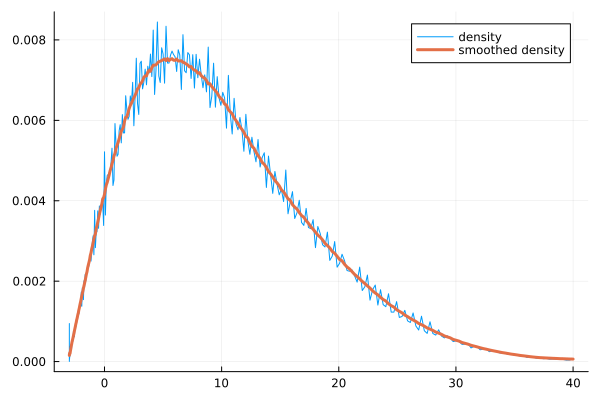

In [17]:
# Moving average smoothing
y = vec(sum(res.mea0, dims=1))
window = 20
y_smooth = [mean(y[max(1,i-window÷2):min(length(y),i+window÷2)]) for i in 1:length(y)]
plot(res.grid1, vec(sum(res.mea0, dims=1)), label="density", linewidth = 1)
plot!(res.grid1, y_smooth, label="smoothed density", linewidth = 3)


### おまけ：総資産供給曲線を求める

In [18]:
function derive_capital_supply_curve(m, r0_grid; tau=0)

    # Pre-declare everything you want to survive the loop
    K0_grid   = zeros(length(r0_grid))
    K1_grid   = zeros(length(r0_grid))

    for (i, rate0) in enumerate(r0_grid)
        # step 1
        K0 = calculate_K0(m, rate0)
        w0 = calculate_w0(m, rate0)

        # step 2
        grids = generate_capital_grid(m, rate0, w0);
        capital_grid_translations = translate_capital_grid(m, grids);

        # step 3
        kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations; tau=tau);

        # step 4
        mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)
        # K1 = calculate_capital_supply(mea0, kfun)
        K1 = calculate_capital_supply(mea0, grids)
        K1_grid[i] = K1

        K0_grid[i] = m.labor*(m.alpha/(rate0+m.delta))^(1/(1-m.alpha)); # caputal demand

    end

    return (; K0_grid, K1_grid)

end

derive_capital_supply_curve (generic function with 1 method)

In [19]:
r0_grid = 0.026:0.001:0.030
K_grids = derive_capital_supply_curve(m, r0_grid);

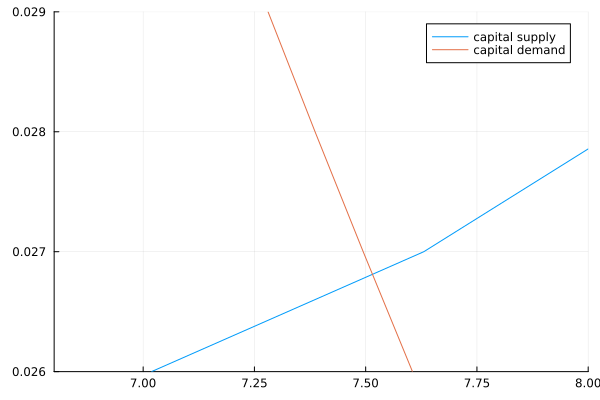

In [27]:
plot(K_grids.K1_grid, r0_grid, label="capital supply")
plot!(K_grids.K0_grid, r0_grid, label="capital demand")
xlims!(6.8, 8)
ylims!(0.026, 0.029)
# plot!([res.K1], [res.rate0], seriestype=:scatter, label="")

## 移行過程を求める

1. 始点（税導入前の定常状態）と終点（税導入後の定常状態）を求める
2. 移行過程での資産需要 $\{K_t\}_{t=0}^T$ を当て推量し、それに基づき利子率 $\{r_t\}_{t=0}^T$ と税収入 $\{\xi_t\}_{t=0}^T$ 求める
3. 終点の価値関数とステップ2の当て推量した流列から、各期での政策関数を求める
4. 求めた政策変数と始点での状態変数の分布から、各期での状態変数の分布を求め、各期での総資産供給を求める
5. 各期で資産の需給が一致するかを確認し、一致しない場合、当て推量した資産需要を更新しステップ3に戻る

元コードに従って、ここでは借入の下限を0とする（つまり借入できないこととする）。

In [21]:
m_transition = Model(
    mu, beta, delta, alpha, 0.0, Nl, s, prob, labor, Nk, maxK, curvK, Nk2, NT
    )

Model{Int64, Float64}(3.0, 0.96, 0.08, 0.36, 0.0, 7, [0.36787944117144233, 0.513417119032592, 0.7165313105737893, 1.0, 1.3956124250860895, 1.9477340410546757, 2.718281828459045], [0.27983446359970576 0.31887186208321794 … 0.002810144610403964 0.00016961862465059152; 0.13933024744962205 0.26196342686745416 … 0.011200993990752138 0.0010234786642925318; … ; 0.0010234786642925847 0.011200993990752143 … 0.2619634268674542 0.13933024744962208; 0.000169618624650619 0.0028101446104039445 … 0.318871862083218 0.27983446359970576], 1.1257073925246666, 300, 40.0, 2.0, 800, 200)

In [22]:
grids = generate_capital_grid(m_transition);
capital_grid_translations = translate_capital_grid(m_transition, grids);

### ステップ1：始点と終点の定常状態を求める

In [23]:
res_SS0 = solve_stationary_equilibrium(m_transition; adj=0.0002, rate0=0.023);

r0: 0.023, K0: 7.954, K1: 7.93
r0: 0.0232, K0: 7.93, K1: 8.039


In [25]:
r_SS0 = res_SS0.rate0;
K_SS0 = res_SS0.K1;
T_SS0 = r_SS0 * K_SS0 * 0;
v_SS0 = res_SS0.v;
mea_SS0 = res_SS0.mea0;

In [26]:
tau = 0.1;
res_SS1 = solve_stationary_equilibrium(m_transition; tau=tau, adj=0.0002, rate0=0.025);

r0: 0.025, K0: 7.719, K1: 7.504
r0: 0.0252, K0: 7.696, K1: 7.477
r0: 0.0254, K0: 7.673, K1: 7.696


In [28]:
r_SS1 = res_SS1.rate0;
K_SS1 = res_SS1.K1;
T_SS1 = r_SS1 * K_SS1 * tau;
v_SS1 = res_SS1.v;
mea_SS1 = res_SS1.mea0;

### ステップ2：移行過程での資産需要を当て推量し、それに基づき利子率と税収入を求める

今度は$K_t$から$r_t$と税収入$\xi_t = \tau r_t K_t$を求める。
元のコードでは税収入はこのように求めるのではなく$K_t$のように各期で当て推量しているが、$K_t$が求まれば$\xi_t$も決まるはずなので、ここでは後者を計算して求めている。

In [29]:
function make_initial_guesses(m, K_SS0, K_SS1)

    # ============================== #
    #  INITIAL GUESS OF KT0 and TT0  #
    # ============================== #

    KT0 = K_SS1 .* ones(m.NT);
    # TT0 = T_SS1 .* ones(m.NT);

    # NT0 = 30; # considering relatively quick convergence to the new steady state
    NT0 = m.NT;

    intK=(K_SS1-K_SS0)/(NT0-1);
    # intT=(T_SS1-T_SS0)/(NT0-1);

    for tc=1:NT0
        KT0[tc] = K_SS0+intK*(tc-1);
        #TT0[tc] = T_SS0+intT*(tc-1);    # let T to jump to final SS value
    end

    # ================================ #
    #  rT0 BASED ON INITIAL GUESS KT0  #
    # ================================ #

    rT0 = zeros(m.NT);

    for tc in 1:m.NT
        rT0[tc] = m.alpha * ((KT0[tc] / m.labor)^(m.alpha - 1)) - m.delta;
    end

    TT0 = KT0 .* rT0 .* tau;

    return TT0, KT0, rT0
end

make_initial_guesses (generic function with 1 method)

In [30]:
TT0, KT0, rT0 = make_initial_guesses(m_transition, K_SS0, K_SS1);

### ステップ3：終点の価値関数とステップ2の当て推量した流列から、各期での政策関数を求める

ステップ1で求めた最終定常状態（T期）での価値関数を使ってT-1期のベルマン方程式をたて、T-1期での各状態での政策関数を求める。
同様に後ろ向きに政策関数を求めていく。
ここでも定常均衡を求めた時と同様、グリッドサーチを使っている。

In [31]:
function compute_value_function_backwards!(
    vfun0, kfunGT, kfunT, m, tc, TT0, KT0, rT0, 
    grids, capital_grid_translations, tau
    )

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    r0 = rT0[tc];
    T0 = TT0[tc];
    # wage = (1-m.alpha)*((m.alpha/(r0+m.delta))^m.alpha)^(1/(1-m.alpha));
    wage = calculate_w0(m, r0);

    # initialization
    kfunG = zeros(m.Nl,m.Nk); # solution grid
    vfun1 = zeros(m.Nl,m.Nk); # new value function
    kfun = zeros(m.Nl,m.Nk);  # solution level

    for kc in 1:m.Nk
        for lc in 1:m.Nl

            vtemp = -1000000 .* ones(m.Nk2); 
            kccmax = m.Nk2;

            for kcc in 1:m.Nk2 

                cons = (
                    m.s[lc] * wage + (1 + r0 * (1 - tau)) * gridk[kc] - gridk2[kcc] + T0
                ); # NOTE: gridk2[kcc] & r0 & T0

                if cons <= 0.0
                    kccmax = kcc-1; 
                    break  
                end

                # util = (cons^(1.0-m.mu)-1.0) / (1.0-m.mu);
                util = (cons^(1.0-m.mu)) / (1.0-m.mu);

                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);
            
                vpr = 0.0; 
                for lcc in 1:m.Nl 

                    vpr += (
                        m.prob[lc,lcc] * (
                            prk1vec[kcc] * vfun0[lcc,kcc1] + prk2vec[kcc] * vfun0[lcc,kcc2]
                        )
                    );
            
                end

                vtemp[kcc] = util + m.beta * vpr;

            end

            t1, t2 = findmax(vtemp[1:kccmax]);
            vfun1[lc,kc] = t1;
            kfunG[lc,kc] = t2;        # solution grid from gridk2
            kfun[lc,kc] = gridk2[t2]; # solution capital(level)

        end

    end

    # update vfun0 for next period (tc-1)
    vfun0[:, :] .= vfun1;
    
    # update policy function (solution grid)
    kfunGT[tc,:,:] .= kfunG;

    # update capital (level)
    kfunT[tc,:,:] .= kfun;

    return nothing

end

compute_value_function_backwards! (generic function with 1 method)

In [32]:
vfun0 = copy(res_SS1.v);

# policy function(initialization)
kfunGT = zeros(m_transition.NT, m_transition.Nl, m_transition.Nk);
kfunT = similar(kfunGT);

tc = m_transition.NT;

In [33]:
compute_value_function_backwards!(
    vfun0, kfunGT, kfunT, m_transition, tc, TT0, KT0, rT0, 
    grids, capital_grid_translations, tau
)


In [34]:
function compute_all_value_function_backwards(
    m, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
    )

    # policy function(initialization)
    kfunGT = zeros(m.NT,m.Nl,m.Nk);
    kfunT = similar(kfunGT);

    vfun0 = copy(v_SS1);

    for tc in NT:-1:1
        compute_value_function_backwards!(
            vfun0, kfunGT, kfunT, m, tc, TT0, KT0, rT0, grids, capital_grid_translations, tau
        )
    end

    return kfunGT, kfunT
end

compute_all_value_function_backwards (generic function with 1 method)

In [35]:
kfunGT, kfunT = compute_all_value_function_backwards(
    m_transition, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
    );

### ステップ4：各期での状態変数の分布を求め、総資産供給を求める

今度は第一期から前向きに、各期での状態変数の分布を求めていく。
具体的には、第一期の状態変数の定常分布からスタートし、上で求めた政策関数を使って次の期の状態変数の分布を求める。

In [36]:
function compute_distribution_t(m, kfunGT, capital_grid_translations, mea_SS0)

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    # ==================================================== #
    # COMPUTE DISTRIBUTION meaT: FROM t=1 TO NT (FORWRAD)  #
    # ==================================================== #

    meaT = zeros(m.NT,m.Nl,m.Nk); # initialization
    meaT[1,:,:] .= copy(mea_SS0); # dist in the initial SS
    
    mea0 = mea_SS0;

    for tc in 1:m.NT-1

        kfunG = copy(kfunGT[tc,:,:]);
        mea1 = zeros(m.Nl,m.Nk); # initialization 

        for kc in 1:m.Nk
            for lc in 1:m.Nl
            
                kcc = Int(kfunG[lc,kc]); # from gridk2

                # split to two grids in gridk
                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);

                for lcc in 1:Nl

                    mea1[lcc,kcc1] += prob[lc,lcc]*prk1vec[kcc]*mea0[lc,kc];
                    mea1[lcc,kcc2] += prob[lc,lcc]*prk2vec[kcc]*mea0[lc,kc];
                
                end
            end
        end

        meaT[tc+1,:,:] = copy(mea1);
        mea0 = copy(mea1);

    end

    return meaT
end

compute_distribution_t (generic function with 1 method)

In [37]:
meaT = compute_distribution_t(m_transition, kfunGT, capital_grid_translations, mea_SS0);

上で求めた各期での状態変数の分布から、総資本供給が求められる。
ここではt期の状態変数の分布とt期の政策関数を使ってt+1期の総資本供給を求めているが、政策関数を使わなくても、資産のグリッドの値と状態変数の分布を使えば各期の総資本供給は求められる。

In [38]:
function compute_capital(m, KT0, kfunT, meaT)
    # ============ #
    #  COMPUTE KT1 #
    # ============ #

    KT1 = zeros(m.NT);
    KT1[1] = KT0[1]; # predetermined

    for tc in 1:m.NT-1

        kfun = copy(kfunT[tc,:,:]); # saving for the next period
        mea0 = meaT[tc,:,:];

        KT1[tc+1] = sum(mea0 .* kfun); #capital at the beggining of next period
    end

    return KT1

end

compute_capital (generic function with 1 method)

In [39]:
KT1 = compute_capital(m_transition, KT0, kfunT, meaT);

### ステップ5：各期で資産の需給が一致するかを確認し、一致しない場合、当て推量した資産需要を更新しステップ3に戻る

当て推量した資産需要　$K_0 = \{K_t\}_{t=1}^{T-1}$ を更新するのは、単純に上で求めた$K_1$を$K_0$とするのではなく、$\lambda K_0 + (1 - \lambda) K_1$を新たな$K_0$とする、という更新の仕方をしている（ここで$\lambda$は0と1の間を取る定数）。
[Nakajima先生のこのノート](https://makotonakajima.github.io/homepage/note-im-aiyagari.pdf)でもこのやり方が説明されている。

In [40]:
function update_variables!(TT0, KT0, rT0, m, KT1, K_SS0, K_SS1, tau; adjK = 0.04)
    KT0 .+= adjK .* (KT1 - KT0);
    KT0 .= (KT0 .- KT0[end]) ./ (KT0[1] - KT0[end]) .* (K_SS0 - K_SS1) .+ K_SS1
    rT0[:] .= m.alpha .* ((KT0 ./ m.labor).^(m.alpha - 1)) .- m.delta
    TT0[:] .= KT0 .* rT0 .* tau

    return nothing
end

update_variables! (generic function with 1 method)

In [41]:
update_variables!(TT0, KT0, rT0, m_transition, KT1, K_SS0, K_SS1, tau)

In [42]:
function derive_transition(m, K_SS0, K_SS1, v_SS1, mea_SS0, tau)

    grids = generate_capital_grid(m);
    capital_grid_translations = translate_capital_grid(m, grids);

    errKTol = 1e-3;
    errK = 1;
    maxiterTR = 100;
    iterTR = 1;

    KT0_iteration_history = zeros(m.NT, maxiterTR);

    TT0, KT0, rT0 = make_initial_guesses(m, K_SS0, K_SS1)

    meaT = zeros(m.NT,m.Nl,m.Nk);

    while (errK > errKTol) && (iterTR < maxiterTR)

        # println(iterTR)

        kfunGT, kfunT = compute_all_value_function_backwards(
            m, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
            );

        meaT = compute_distribution_t(m, kfunGT, capital_grid_translations, mea_SS0);

        KT1 = compute_capital(m, KT0, kfunT, meaT);

        errK = maximum(abs.(KT1 - KT0));
        # println(errK)
        if errK > errKTol
            update_variables!(TT0, KT0, rT0, m, KT1, K_SS0, K_SS1, tau)
        end

        KT0_iteration_history[:, iterTR] = KT0;

        iterTR += 1;

    end

    return KT0, KT0_iteration_history, meaT

end

derive_transition (generic function with 1 method)

In [43]:
KT_transition, KT0_iteration_history, meaT = derive_transition(m_transition, K_SS0, K_SS1, v_SS1, mea_SS0, tau);

In [44]:
rT_transition = m_transition.alpha .* ((KT_transition ./ m_transition.labor).^(m_transition.alpha .- 1)) .- m_transition.delta;

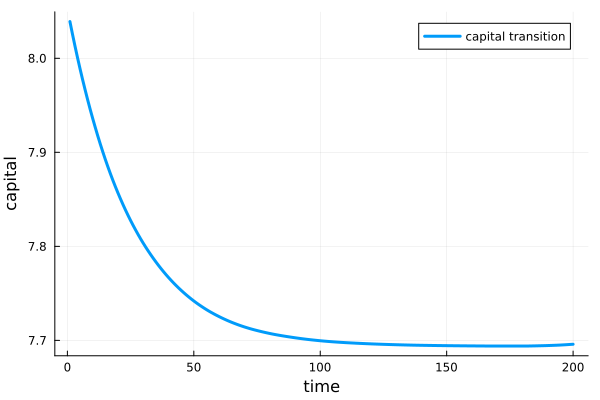

In [45]:
plot(1:NT, KT_transition, label="capital transition", linewidth=3)
xlabel!("time")
ylabel!("capital")

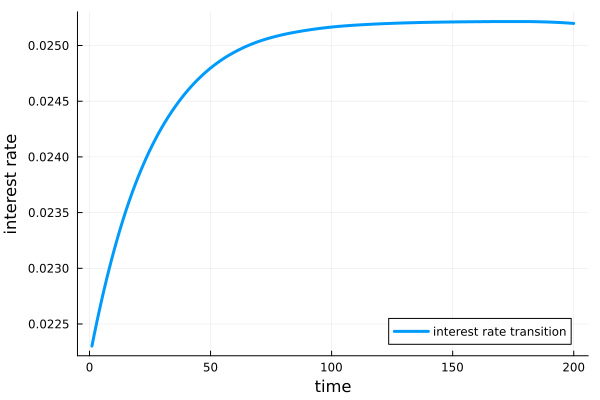

In [46]:
plot(1:NT, rT_transition, label="interest rate transition", linewidth=3)
xlabel!("time")
ylabel!("interest rate")

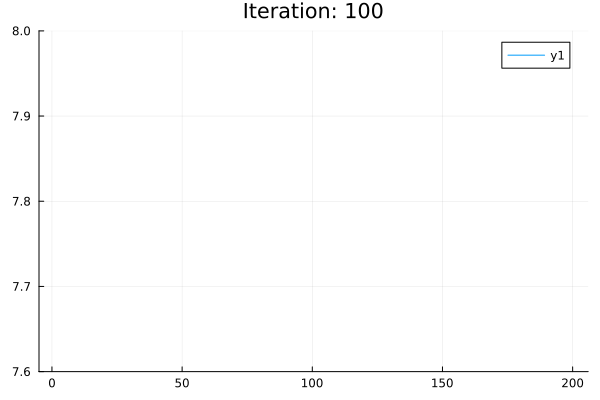

In [52]:
anim = Animation()
for i in 1:100
    current_plot = plot(1:NT, KT0_iteration_history[:, i], title="Iteration: $i")
    plot!(ylims=(7.6, 8.0))
    display(current_plot)
    sleep(0.10)
    frame(anim)
    IJulia.clear_output(true)
end

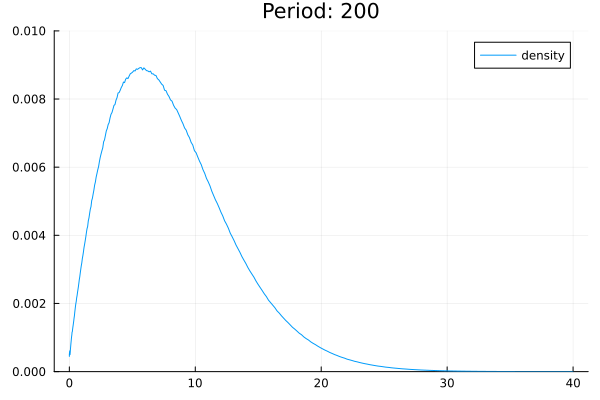

In [48]:
anim = Animation()
for i in 1:m.NT
    y = dropdims(sum(meaT[i, :, :], dims=1), dims=1)
    window = 20
    y_smooth = [mean(y[max(1,i-window÷2):min(length(y),i+window÷2)]) for i in 1:length(y)]
    current_plot = plot(grids[1], y_smooth, title="Period: $i", label="density", linewidth=1)
    ylims!(0, 0.01)
    display(current_plot)
    sleep(0.04)
    frame(anim)
    IJulia.clear_output(true)
end

In [49]:
# quantile of capital distribution
quantiles = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
quantile_values = zeros(m.NT, length(quantiles))
for i in 1:m.NT
    y = dropdims(sum(meaT[i, :, :], dims=1), dims=1)
    cumulative = cumsum(y)
    for (j, q) in enumerate(quantiles)
        idx = findfirst(cumulative .>= q)
        quantile_values[i, j] = grids[1][idx]
    end
end

In [50]:
quantile_values

200×7 Matrix{Float64}:
 0.216552  1.83264  3.78698  6.99097  11.1695   15.6459  24.9196
 0.216552  1.83264  3.78698  6.87957  11.0285   15.479   24.7089
 0.216552  1.83264  3.78698  6.87957  10.8885   15.479   24.4991
 0.216552  1.83264  3.7051   6.87957  10.8885   15.313   24.4991
 0.197313  1.77582  3.7051   6.76905  10.8885   15.1479  24.2901
 0.197313  1.77582  3.7051   6.76905  10.7493   15.1479  24.0821
 0.197313  1.77582  3.62412  6.76905  10.6111   14.9837  23.8749
 0.197313  1.71989  3.62412  6.65943  10.6111   14.9837  23.6686
 0.197313  1.71989  3.62412  6.65943  10.4737   14.8204  23.6686
 0.197313  1.71989  3.62412  6.55071  10.4737   14.8204  23.4633
 0.197313  1.71989  3.54403  6.55071  10.4737   14.658   23.4633
 0.178969  1.71989  3.54403  6.55071  10.3372   14.4965  23.2588
 0.178969  1.71989  3.54403  6.44288  10.3372   14.4965  23.0552
 ⋮                                               ⋮       
 0.129305  1.40312  3.00847  5.61247   9.02182  12.628   19.9197
 0.129305

In [51]:
quantile_values[end, :] ./ quantile_values[1, :]

7-element Vector{Float64}:
 0.5971074380165288
 0.765625
 0.8139177693761812
 0.8172160000000002
 0.8077231212946646
 0.807114873173382
 0.7993572249353632

## 計算方法を少し変えてみたバージョン
- aiygagari_continous.jl: 次期の資産を、グリッドサーチではなく、連続の変数としてVFIを解く
- aiygagari_continous_root.jl: 定常均衡を見つける時、利子率を段階的に上げていくのではなく、資産の需給がちゃんと一致するような利子率を求める